In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests
from datetime import datetime, timedelta

sns.set_theme(style="whitegrid")

In [ ]:
def fetch_actuals(start_date, end_date):
    url = f"https://data.elexon.co.uk/bmrs/api/v1/datasets/FUELHH?settlementDateFrom={start_date}&settlementDateTo={end_date}"
    res = requests.get(url).json()
    if 'data' not in res:
        return pd.DataFrame()
    df = pd.DataFrame(res['data'])
    df = df[df['fuelType'] == 'WIND']
    df['startTime'] = pd.to_datetime(df['startTime'])
    return df[['startTime', 'generation']].rename(columns={'generation': 'actual_generation'})


In [4]:
def fetch_forecasts(start_time, end_time):
    url = f"https://data.elexon.co.uk/bmrs/api/v1/datasets/WINDFOR?publishDateTimeFrom={start_time}&publishDateTimeTo={end_time}"
    res = requests.get(url).json()
    if 'data' not in res:
        return pd.DataFrame()
    df = pd.DataFrame(res['data'])
    df['startTime'] = pd.to_datetime(df['startTime'])
    df['publishTime'] = pd.to_datetime(df['publishTime'])
    return df[['startTime', 'publishTime', 'generation']].rename(columns={'generation': 'forecast_generation'})


In [6]:
# fetch month data
start_date = '2025-01-01'
end_date = '2025-01-07' # Using 1 week for demonstration due to API limits

actuals_df = fetch_actuals(start_date, end_date)
forecasts_df = fetch_forecasts(f"{start_date}T00:00:00Z", f"{end_date}T23:59:59Z")

In [9]:
forecasts_df['horizon_hours'] = (forecasts_df['startTime'] - forecasts_df['publishTime']).dt.total_seconds() / 3600
forecasts_df = forecasts_df[(forecasts_df['horizon_hours'] >= 0) & (forecasts_df['horizon_hours'] <= 48)]

merged_df = pd.merge(forecasts_df, actuals_df, on='startTime', how='inner')
merged_df['error'] = merged_df['forecast_generation'] - merged_df['actual_generation']
merged_df['abs_error'] = merged_df['error'].abs()
merged_df['ape'] = merged_df['abs_error'] / merged_df['actual_generation'].replace(0, np.nan) * 100

In [10]:
print("Overall Absolute Error Metrics (MW):")
print(f"Mean: {merged_df['abs_error'].mean():.2f}")
print(f"Median: {merged_df['abs_error'].median():.2f}")
print(f"P99: {merged_df['abs_error'].quantile(0.99):.2f}")

Overall Absolute Error Metrics (MW):
Mean: 1543.75
Median: 1162.00
P99: 5407.06


C:\Users\HP\AppData\Local\Temp\ipykernel_6352\3397090213.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  horizon_grouped = merged_df.groupby('horizon_bin')['abs_error'].mean().reset_index()


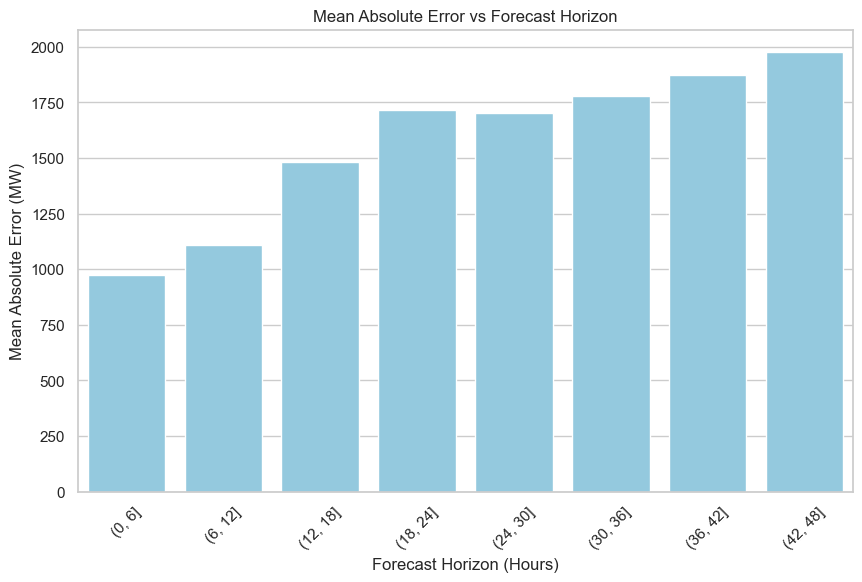

In [11]:
merged_df['horizon_bin'] = pd.cut(merged_df['horizon_hours'], bins=range(0, 50, 6))
horizon_grouped = merged_df.groupby('horizon_bin')['abs_error'].mean().reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(data=horizon_grouped, x='horizon_bin', y='abs_error', color='skyblue')
plt.title('Mean Absolute Error vs Forecast Horizon')
plt.xlabel('Forecast Horizon (Hours)')
plt.ylabel('Mean Absolute Error (MW)')
plt.xticks(rotation=45)
plt.show()

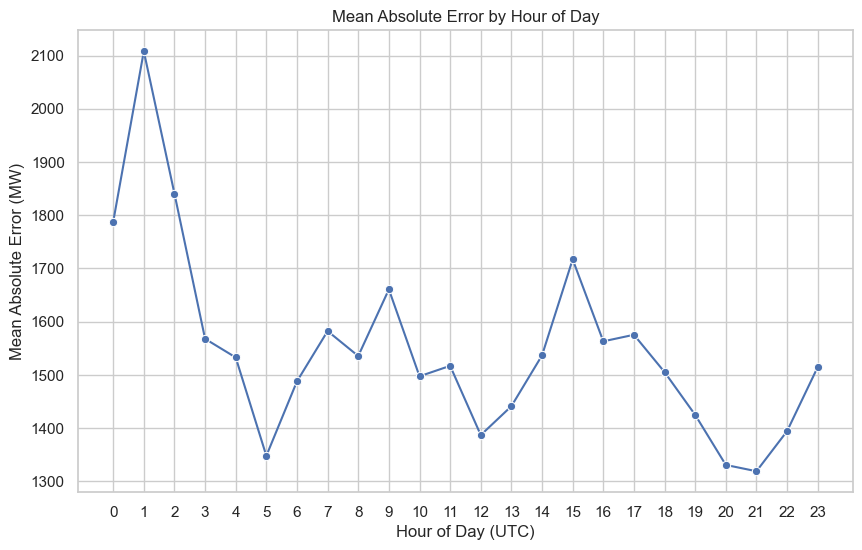

In [12]:
merged_df['hour_of_day'] = merged_df['startTime'].dt.hour
hourly_error = merged_df.groupby('hour_of_day')['abs_error'].mean().reset_index()

plt.figure(figsize=(10, 6))
sns.lineplot(data=hourly_error, x='hour_of_day', y='abs_error', marker='o')
plt.title('Mean Absolute Error by Hour of Day')
plt.xlabel('Hour of Day (UTC)')
plt.ylabel('Mean Absolute Error (MW)')
plt.xticks(range(0, 24))
plt.show()

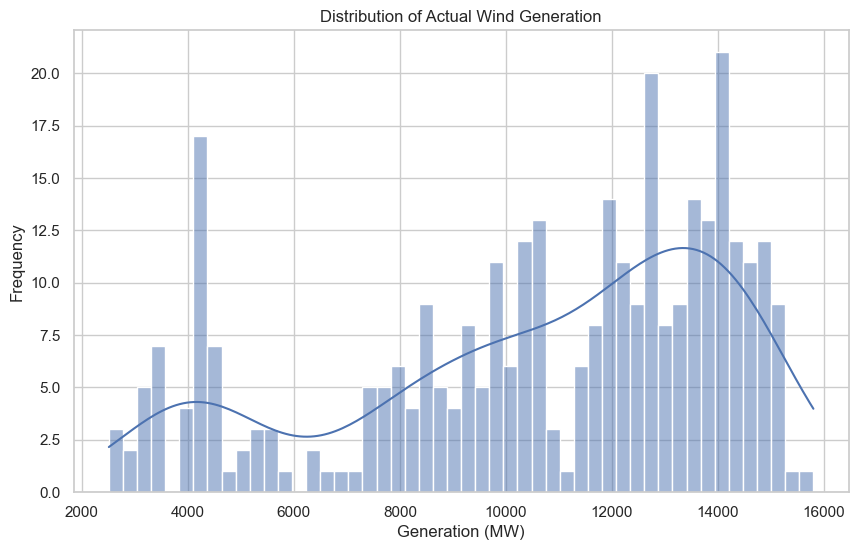

P90 Generation (exceeded 90% of the time): 4304.50 MW
P95 Generation (exceeded 95% of the time): 3801.00 MW
P99 Generation (exceeded 99% of the time): 2966.45 MW


In [13]:
plt.figure(figsize=(10, 6))
sns.histplot(actuals_df['actual_generation'], bins=50, kde=True)
plt.title('Distribution of Actual Wind Generation')
plt.xlabel('Generation (MW)')
plt.ylabel('Frequency')
plt.show()

p90_generation = actuals_df['actual_generation'].quantile(0.10)
p95_generation = actuals_df['actual_generation'].quantile(0.05)
p99_generation = actuals_df['actual_generation'].quantile(0.01)

print(f"P90 Generation (exceeded 90% of the time): {p90_generation:.2f} MW")
print(f"P95 Generation (exceeded 95% of the time): {p95_generation:.2f} MW")
print(f"P99 Generation (exceeded 99% of the time): {p99_generation:.2f} MW")